# Optical Water Types (OWT) retrieval

This tutorial shows how to classify every water pixel of a GRS Level-2A image into
**Optical Water Types** (OWT) with GRSl2bgen. An OWT groups waters with similar
reflectance spectra, and therefore similar optical constituents (phytoplankton,
sediments, CDOM). The OWT map is used later to select the most suitable retrieval
algorithms, see the {doc}`grsl2bgen_owt_blending` tutorial.

You will:

1. open a GRS L2A product and look at its content;
2. classify the image against the 13 inland-water OWT of Spyrakos et al. (2018);
3. repeat the classification with the 10 OWT of Bi and Hieronymi (2024);
4. compute the area covered by each OWT and inspect the corresponding spectra.

The mathematical description of the classification is given in {doc}`../algorithms`.

In [1]:
import warnings
warnings.filterwarnings('ignore')   # keep the notebook output readable

import logging

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import rioxarray  # noqa: F401, registers the .rio accessor
import cartopy.crs as ccrs

import GRSl2bgen

logging.getLogger().setLevel(logging.WARNING)

# lighter figures for the documentation
%config InlineBackend.figure_formats = ['jpeg']
plt.rcParams['figure.dpi'] = 72

print(f'GRSl2bgen {GRSl2bgen.__version__}')

GRSl2bgen 1.0.0


## Set the input path

`l2a_path` points to a GRS L2A product produced by
[GRSprocessor](https://github.com/CNES/GRSprocessor). It can be a `.nc` file, a `.zarr`
store, or a directory containing `<name>.nc` and its `<name>_anc.nc` ancillary file.
Replace it with the path of your own image.

In [2]:

l2a_path ='/data/satellite/Sentinel-2/subset/L2A/ambracian/2024/07/06/S2B_MSIL2A_20240706T091559_N0510_R093_T34SDJ_20240706T101118'

## Open and check the input L2A image

{py:class}`GRSl2bgen.product.Product` loads the product lazily (with dask) as an
`xarray.Dataset`. The main variables are:

- `Rrs`: remote-sensing reflectance $R_{rs}(\lambda)$ in sr$^{-1}$, with dimensions
  `(wl, y, x)` (wavelength in nm);
- `BRDFg`: sunglint reflectance removed by GRS;
- `mask` and `flags`: pixel classification and quality flags (water pixels have
  `mask == 0`).

In this example the image is a Sentinel-2/MSI subset of 3206 x 4400 pixels (resampled
to 8.4 x 10 m) with 11 bands (443, 490, 560, 665, 705, 740, 783, 842, 865, 1610 and 2190 nm). The
data are read in chunks of 1024 x 1024 pixels only when needed, so opening even a
full tile is instantaneous.

In [3]:
prod = GRSl2bgen.Product(l2a_path)
prod.raster

<xarray.Dataset> Size: 2GB
Dimensions:             (wl: 11, y: 3206, x: 4400)
Coordinates:
  * wl                  (wl) int64 88B 443 490 560 665 705 ... 842 865 1610 2190
    time                datetime64[ns] 8B ...
  * x                   (x) float64 35kB 4.728e+05 4.728e+05 ... 5.097e+05
  * y                   (y) float64 26kB 4.331e+06 4.331e+06 ... 4.299e+06
    central_wavelength  (wl) float32 44B dask.array<chunksize=(11,), meta=np.ndarray>
    spatial_ref         int64 8B ...
Data variables:
    Rrs                 (wl, y, x) float64 1GB dask.array<chunksize=(11, 1024, 1024), meta=np.ndarray>
    BRDFg               (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    aot550              (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    wind                (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    mask                (y, x) uint8 14MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    vza                 (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    sza                 (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    raa                 (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    flags               (y, x) int64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    dem                 (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
Attributes: (12/73)
    long_name:                           CA BLUE GREEN RED VRE_1 VRE_2 VRE_3 ...
    constellation:                       Sentinel-2
    constellation_id:                    S2
    product_path:                        /data/satellite/Sentinel-2/L1C/34SDJ...
    product_name:                        S2B_MSIL1C_20240706T091559_N0510_R09...
    product_filename:                    S2B_MSIL1C_20240706T091559_N0510_R09...
    ...                                  ...
    vis_swir_index_threshold:            0.0
    hcld_threshold:                      0.003
    dirdata:                             /data/grs/grsdata
    abs_gas_file:                        /home/harmel/anaconda3/envs/py12/lib...
    water_vapor_transmittance_file:      /home/harmel/anaconda3/envs/py12/lib...
    metadata_profile:                    datacube

Get the map projection (UTM zone), pixel size and acquisition date, used for the
figures and for area computations below.

In [4]:
raster = prod.raster
crs = raster.rio.crs
str_epsg = str(crs)
zone = str_epsg[-2:]
is_south = str_epsg.split(':')[-1].startswith('327')   # EPSG:327xx = UTM south
proj = ccrs.UTM(zone, is_south)
x_res, y_res = raster.rio.resolution()
pixel_area = np.abs(x_res*y_res)
date = str(raster.time.dt.strftime('%Y/%m/%d').values)

Quick look at the image: true-colour composite built from $R_{rs}$ (left) and sunglint
reflectance estimated by GRS (right).

The composite uses the bands closest to 670, 565 and 490 nm (i.e. 665, 560 and
490 nm) with a robust colour stretch (2nd--98th percentiles). Sunglint is a major
source of uncertainty: check that it is low (or well corrected) over the water body
before interpreting the products.

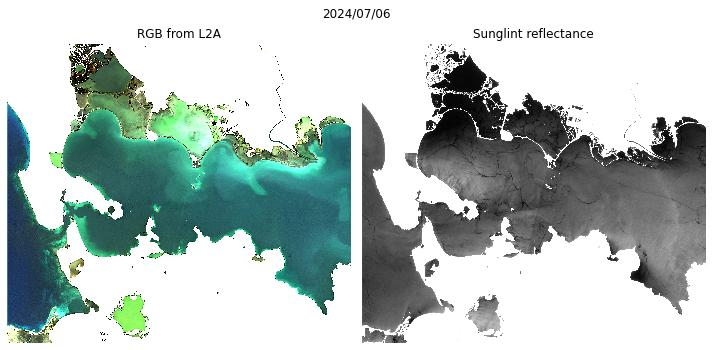

In [5]:


nrows=1
ncols=2
alpha=0.3
l2a_rgb = raster.Rrs.sel(wl= [670,565,490],method='nearest' )
fig,axs = plt.subplots(nrows,ncols,figsize=(ncols*5.,5*nrows),subplot_kw={'projection': proj}) 
fig.subplots_adjust(bottom=0.08, top=0.9, left=0.086, right=0.98,
                    hspace=0.05, wspace=0.07,)
if (ncols == 1) & (nrows == 1):
    axs = np.array([axs])
axs=axs.ravel()
[axi.set_axis_off() for axi in axs]   

ax=axs[0]


bcmap = mpl.colors.ListedColormap([(0,0,0,0),'green','blue'])
# omni_mask.plot.imshow(cmap=bcmap,alpha=alpha,add_colorbar=False,ax=ax)
l2a_rgb.plot.imshow(rgb='wl', robust=True,ax=ax)
raster['BRDFg'].plot.imshow(cmap=plt.cm.gray, robust=True,vmin=0,vmax=0.04,ax=axs[1],add_colorbar=False)
 

ax.set_title("RGB from L2A")
axs[1].set_title("Sunglint reflectance")

#cbar_ax = fig.add_axes([0.3, 0.0, 0.4, 0.02])  # Left, bottom, width, height.
#cbar = fig.colorbar(im, cax=cbar_ax, extend='both', orientation='horizontal')
#cbar.set_label('$SPM\ (mg\cdot L^{-1})$')
plt.suptitle(date)
plt.tight_layout()

## OWT classification with Spyrakos et al. (2018)

The database of [Spyrakos et al. (2018)](https://aslopubs.onlinelibrary.wiley.com/doi/10.1002/lno.10674)
contains the mean spectra of 13 OWT found in inland and coastal waters, derived from
a clustering of in situ reflectance spectra.

### Standardised spectra

To compare spectral **shapes** independently of the brightness of the water, the
spectra of the database are standardised by their integral over 400--800 nm:

$$
nR_{rs}(\lambda) = \frac{R_{rs}(\lambda)}{\displaystyle\int_{400}^{800} R_{rs}(\lambda')\,\mathrm{d}\lambda'}
\qquad [\mathrm{nm}^{-1}]
$$

so that every standardised spectrum has a unit area.

### Spectral Angle Mapper

The database spectra are interpolated on the wavelengths of the image, and only the
bands between 350 and 800 nm are used (443, 490, 560, 665, 705, 740 and 783 nm for
Sentinel-2/MSI). Each pixel spectrum $\mathbf{R} = [R_{rs}(\lambda_1), \dots, R_{rs}(\lambda_N)]$
is compared with the spectrum $\mathbf{R}_j$ of each class $j$ with the
**Spectral Angle Mapper** (SAM):

$$
\theta_j = \arccos\left(\frac{\sum_{i=1}^{N} R_{rs}(\lambda_i)\,R_j(\lambda_i)}
{\sqrt{\sum_{i=1}^{N} R_{rs}(\lambda_i)^2}\,\sqrt{\sum_{i=1}^{N} R_j(\lambda_i)^2}}\right),
\qquad j = 1, \dots, 13
$$

$\theta_j$ is the angle between the two spectra seen as vectors in an $N$-dimensional
space: $\theta_j = 0$ for identical shapes, whatever their magnitude (multiplying
$\mathbf{R}$ by any positive factor does not change $\theta_j$). This is why the
pixel $R_{rs}$ (in sr$^{-1}$) can be compared directly with the standardised
spectra (in nm$^{-1}$). As an order of magnitude, $0.1$ rad $\approx 5.7°$.

The pixel is assigned to the class with the smallest angle,
$c_1 = \arg\min_j \theta_j$. Classes can also be ranked by increasing angle to keep
the $K$ best ones, $\theta_{(1)} \le \theta_{(2)} \le \dots \le \theta_{(K)}$.

### Euclidean distance (option)

With `spectral_distance='euclidean'`, the Euclidean distance is used instead:

$$
d_j = \sqrt{\sum_{i=1}^{N} \left[R_{rs}(\lambda_i) - R_j(\lambda_i)\right]^2}
$$

Unlike the SAM, $d_j$ depends on the magnitude of the spectra, so the reference
spectra must be in the same unit as the pixel spectra (e.g. `param='m_Rrs'` for the
Bi2024 database).

### Settings

{py:class}`GRSl2bgen.owt.OWT` prepares the classification. By default only the best
class is kept (`Nclasses_to_be_saved=1`).

In [6]:
OWT = GRSl2bgen.OWT(prod.raster,
                    owt_database='Spyrakos2018')

Mean spectra of the 13 OWT. They are standardised, $nR_{rs}$, hence the unit
nm$^{-1}$ and the unit area under each curve:

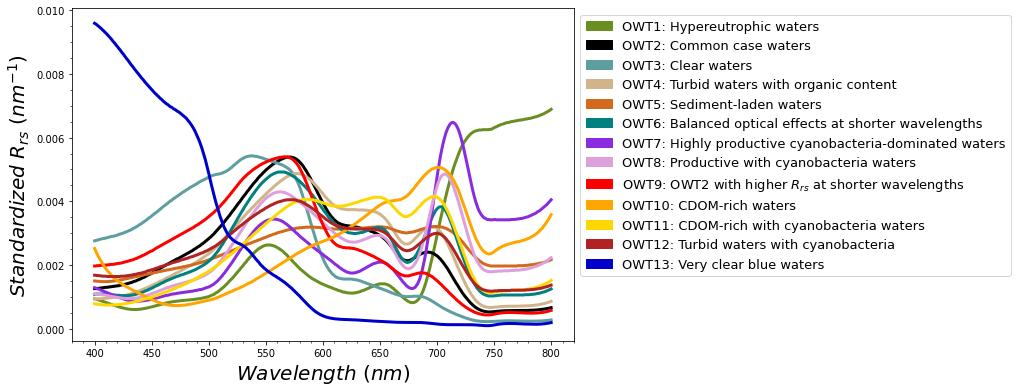

In [7]:
OWT.plot();

Run the classification. With dask-backed input the computation is lazy: it is
performed chunk by chunk, by a compiled (numba) kernel, when the result is plotted or
written. The result is an `xarray.Dataset` with:

- `owt_index`: class number $c_1$ (1 to 13) of the best-matching OWT;
- `owt_dist`: corresponding spectral angle $\theta_{(1)}$ in radians.

Pixels with a missing band, or outside the water mask, are left undefined (NaN).

In [8]:
xowt_prod = OWT.multi_process()

Map of the OWT (left) and of the spectral angle to the selected class (right). Large
angles flag pixels that are poorly represented by the database (e.g. residual glint,
adjacency effects, or optically shallow waters).

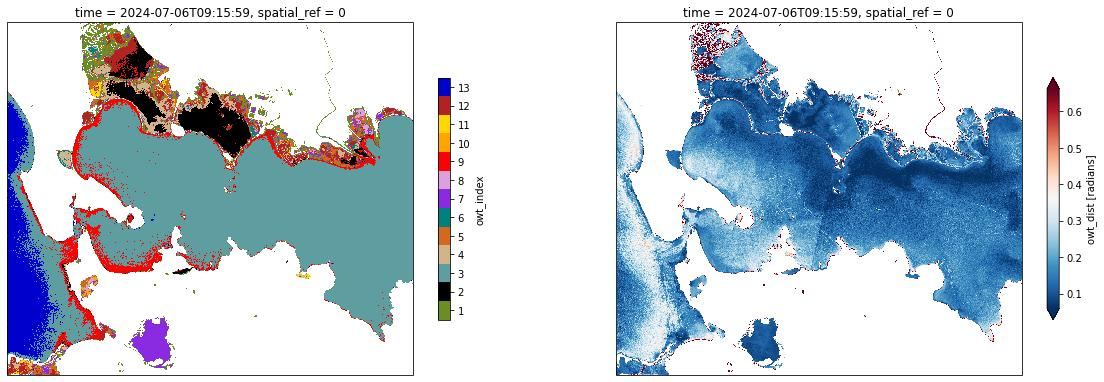

In [9]:
fig = plt.figure(figsize=(20, 15))

ax = plt.subplot(2, 2, 1, projection=proj)
xowt_prod.owt_index.plot.imshow(vmin=0.5,vmax=OWT.Nowt+.5,cmap=OWT.cmap_owt,cbar_kwargs={ 'ticks':range(1,OWT.Nowt+1),'shrink': 0.64},ax=ax)

cmap = plt.get_cmap('RdBu_r')#,13)
ax = plt.subplot(2, 2, 2, projection=proj)
xowt_prod.owt_dist.plot.imshow(robust=True,cmap=cmap,ax=ax, cbar_kwargs={ 'shrink': 0.64});

## Another database: Bi and Hieronymi (2024)

The [Bi and Hieronymi (2024)](https://aslopubs.onlinelibrary.wiley.com/doi/full/10.1002/lno.12606)
classification covers ocean, coastal and inland waters with 10 OWT (400--900 nm). The
class numbers used by GRSl2bgen (1--10) correspond to the following types:

| Index | Type | Description |
|---|---|---|
| 1 | 1 | Extremely clear, oligotrophic indigo-blue waters |
| 2 | 2 | Blue waters, slightly more detritus and CDOM than type 1 |
| 3 | 3a | Turquoise waters, slightly more phytoplankton, detritus and CDOM |
| 4 | 3b | As 3a with strong scattering (e.g. coccolithophore blooms), peak near 490 nm |
| 5 | 4a | Greenish coastal and inland waters, higher biomass |
| 6 | 4b | As 4a with highly scattering blooms, very bright green |
| 7 | 5a | Green eutrophic waters, peaks near 560 and 709 nm |
| 8 | 5b | Hyper-eutrophic waters, vegetation-like plateau in the NIR |
| 9 | 6 | Bright brown waters dominated by detritus scattering |
| 10 | 7 | Dark brown to black waters with very high CDOM |

The same SAM classification is applied: only the reference spectra change. This
notebook uses the standardised mean spectra (`param='m_nRrs'`, default); the
processing chain uses the non-standardised ones (`m_Rrs`, sr$^{-1}$). Because the
SAM ignores the magnitude, both give close results; they differ slightly because the
mean of standardised spectra is not exactly the standardised mean spectrum.

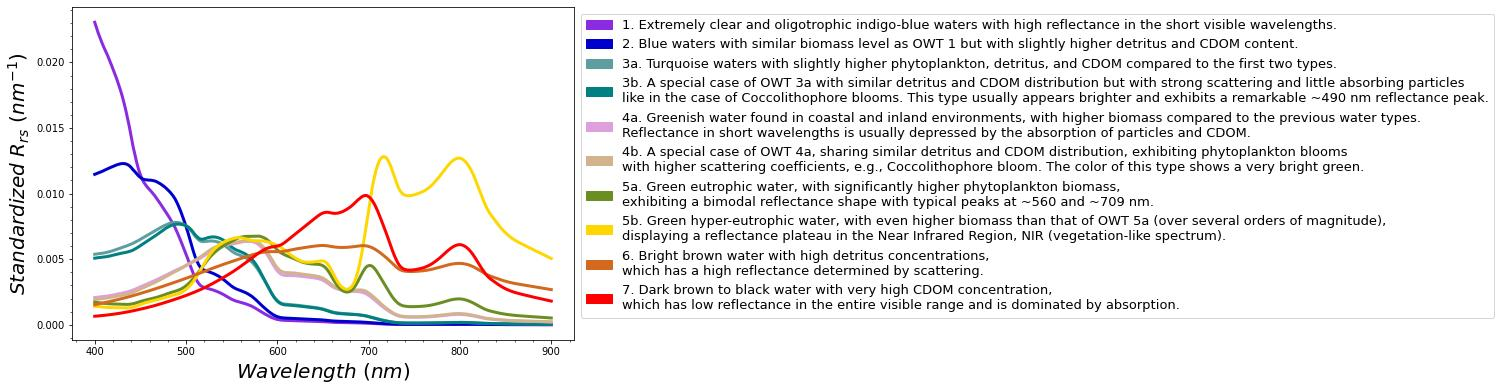

In [10]:
OWT = GRSl2bgen.OWT(prod.raster,
                    owt_database='Bi2024')

OWT.plot();

Classify the image and map the result (left) with the spectral angle (right). For
readability, the class numbers are replaced by the type names (1, 2, 3a, ..., 7) in
the figure.

In [11]:
xowt_prod = OWT.multi_process()

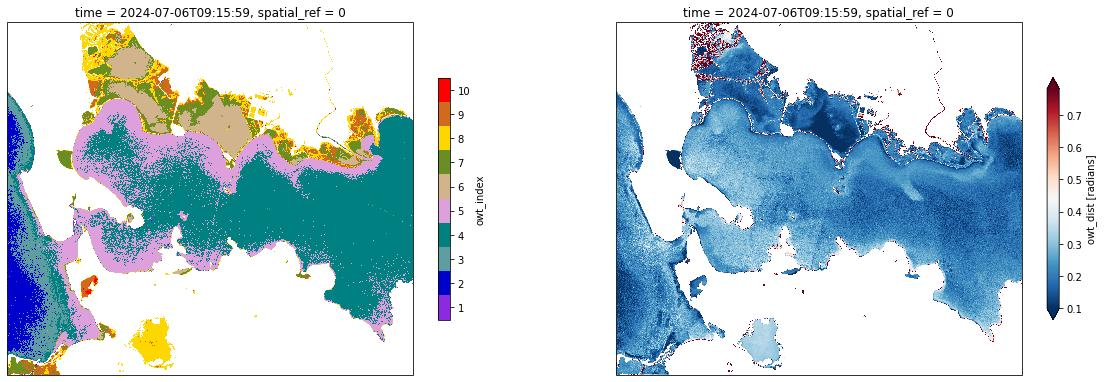

In [12]:
fig = plt.figure(figsize=(20, 15))
OWT.owt['owt']=['1','2','3a','3b','4a','4b','5a','5b','6','7']
ax = plt.subplot(2, 2, 1, projection=proj)
xowt_prod.owt_index.plot.imshow(vmin=0.5,vmax=OWT.Nowt+.5,cmap=OWT.cmap_owt,cbar_kwargs={ 'ticks':range(1,OWT.Nowt+1),'shrink': 0.64},ax=ax)

cmap = plt.get_cmap('RdBu_r')#,13)
ax = plt.subplot(2, 2, 2, projection=proj)
xowt_prod.owt_dist.plot.imshow(robust=True,cmap=cmap,ax=ax, cbar_kwargs={ 'shrink': 0.64});

## Area and spectra of each OWT

Count the pixels assigned to each OWT $j$ to get the area it covers and its share of
the water surface:

$$
A_j = N_j\, |\Delta x\, \Delta y|, \qquad p_j = 100\,\frac{N_j}{N_{\mathrm{water}}}\ (\%)
$$

where $N_j$ is the number of pixels of class $j$, $\Delta x\,\Delta y$ the pixel area
(about 84 m$^2$ for this image) and $N_{\mathrm{water}}$ the number of valid water
pixels.

For each class present in the image, the figure shows the median (black) and mean
(red) $R_{rs}$ spectra of its pixels, with the reference spectrum of the class
(dotted), and gives $p_j$ and $A_j$ (km$^2$) in the title. Since the reference
spectrum is standardised, compare its **shape** with the image spectra, not its
magnitude. A large mismatch in shape means that the class poorly represents these
pixels.

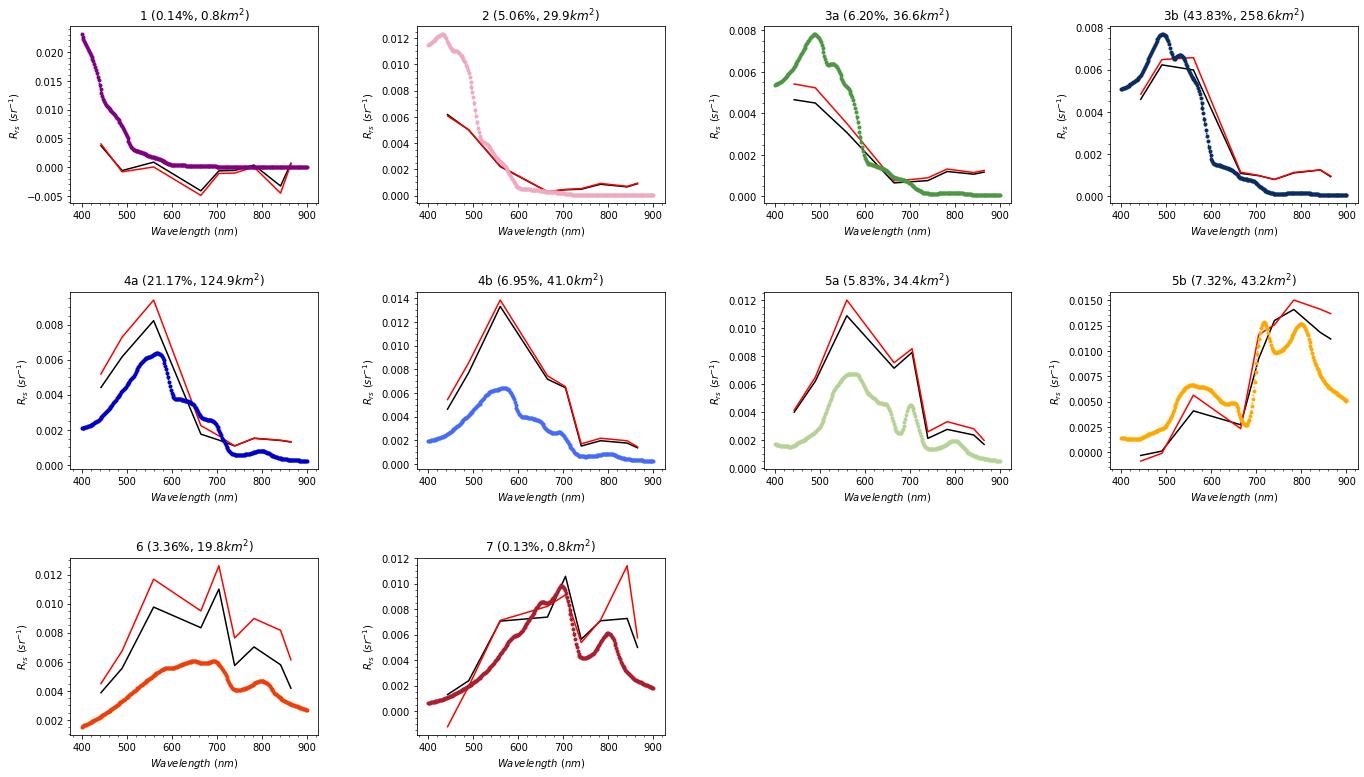

In [13]:
Nowt = OWT.Nowt
owt_roi = np.unique(xowt_prod.owt_index)
owt_roi = owt_roi[~np.isnan(owt_roi)].astype(int)
owt_roi

cmap_ = mpl.colors.LinearSegmentedColormap.from_list("",
                                                    ['purple','pink',
                                                        'forestgreen',#'yellowgreen',
                                                      'navy', "blue", 'lightskyblue',"gold",
                                                     'orangered', "firebrick", 'purple'])
cmap.resampled(Nowt)
color_list = cmap_(np.linspace(0, 1, Nowt, 0))
cmap = cmap_.from_list('',color_list, Nowt)


ncols=4
Nowt_roi = len(owt_roi)
ncols=np.min([ncols,Nowt_roi])
nrows=int(np.ceil(Nowt_roi/ncols))    


norm = mpl.colors.Normalize(vmin=0.5, vmax=Nowt+0.5)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig,axs = plt.subplots(nrows,ncols,figsize=(ncols*5,4*nrows)) 
fig.subplots_adjust(bottom=0.08, top=0.9, left=0.086, right=0.98,
                    hspace=0.5, wspace=0.4)
if (ncols == 1) & (nrows == 1):
    axs = np.array([axs])
axs=axs.ravel()
[axi.set_axis_off() for axi in axs]
Rrs_raster = raster.Rrs.sel(wl=slice(400,1000))
Ntot = Rrs_raster.isel(wl=1).count()
for ii,owt_ in enumerate(owt_roi):
    ax=axs[ii]
    ax.set_axis_on()
    ax.minorticks_on()

    Rrs_roi = Rrs_raster.where(xowt_prod.owt_index==owt_)
    Npix = Rrs_roi.isel(wl=1).count()
    area = Npix*pixel_area*1e-6
    Rrs_roi.median(['x','y']).plot(c='k',label='median',ax=ax)
    Rrs_roi.mean(['x','y']).plot(c='r',label='mean',ax=ax)
    #ax.fill_between(wl, stats['isRrs_q25'], stats['isRrs_q75'],alpha=0.3,color='grey')
    #ax.fill_between(wl, stats['isRrs_min'], stats['isRrs_max'],alpha=0.1,color='grey')
    OWT.owt.isel(owt=owt_-1).plot(c=cmap(norm(owt_)),marker='o',ms=3,ls=':',label='OWT',ax=ax)
    ax.set_xlabel(r'$Wavelength\ (nm)$')
    ax.set_ylabel(r'$R_{rs}\ (sr^{-1})$')
    ax.set_title(str(OWT.owt.owt.values[owt_-1])+f' ({(Npix/Ntot*100).values:.2f}%, {area.values:.1f}'+r'$km^2$)')

## Next steps

- Use the OWT to blend chlorophyll-a algorithms: {doc}`grsl2bgen_owt_blending`.
- Run the full processing chain (OWT, Chl-a, SPM, CDOM, transparency) on an image:
  see the examples in {doc}`../processing_chain`.